In [1]:
import kagglehub
import os
import shutil # Memungkinkan operasi tingkat tinggi pada sejumlah file dan koleksi file
import matplotlib.pyplot as plt
import tensorflow as tf # Untuk komputasi numerik berkinerja tinggi
import keras # Kerangka kerja pembelajaran mendalam multi-backend
import pandas as pd
import numpy as np
import seaborn as sns # Visualisasi data statistik
import cv2 # Pustaka perangkat lunak visi komputer
import warnings
import time

# Menyesuaikan generator data dengan beberapa data sampel
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.model_selection import train_test_split
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras import layers, models
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from tensorflow.keras.preprocessing import image
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
from itertools import cycle

# Menghilangkan peringatan log dari Keras/TensorFlow
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
warnings.filterwarnings('ignore', category=UserWarning)

In [2]:
# Mengunduh dan menetapkan jalur direktori dataset CT-Scan ginjal dari Kaggle secara otomatis.
path = kagglehub.dataset_download("nazmul0087/ct-kidney-dataset-normal-cyst-tumor-and-stone")
print("Jalur ke file dataset: ", path)
dataset_path = path
parent_dir = os.path.join(dataset_path, "CT-KIDNEY-DATASET-Normal-Cyst-Tumor-Stone", "CT-KIDNEY-DATASET-Normal-Cyst-Tumor-Stone")

# Tentukan jalur untuk setiap jenis kasus
normal_cases_path = os.path.join(parent_dir, "Normal")
cyst_cases_path = os.path.join(parent_dir, "Cyst")
tumor_cases_path = os.path.join(parent_dir, "Tumor")
stone_cases_path = os.path.join(parent_dir, "Stone")

# Cetak jalur untuk memverifikasi
print(f"Normal cases path: {normal_cases_path}")
print(f"Cyst cases path: {cyst_cases_path}")
print(f"Tumor cases path: {tumor_cases_path}")
print(f"Stone cases path: {stone_cases_path}")

Using Colab cache for faster access to the 'ct-kidney-dataset-normal-cyst-tumor-and-stone' dataset.
Jalur ke file dataset:  /kaggle/input/ct-kidney-dataset-normal-cyst-tumor-and-stone
Normal cases path: /kaggle/input/ct-kidney-dataset-normal-cyst-tumor-and-stone/CT-KIDNEY-DATASET-Normal-Cyst-Tumor-Stone/CT-KIDNEY-DATASET-Normal-Cyst-Tumor-Stone/Normal
Cyst cases path: /kaggle/input/ct-kidney-dataset-normal-cyst-tumor-and-stone/CT-KIDNEY-DATASET-Normal-Cyst-Tumor-Stone/CT-KIDNEY-DATASET-Normal-Cyst-Tumor-Stone/Cyst
Tumor cases path: /kaggle/input/ct-kidney-dataset-normal-cyst-tumor-and-stone/CT-KIDNEY-DATASET-Normal-Cyst-Tumor-Stone/CT-KIDNEY-DATASET-Normal-Cyst-Tumor-Stone/Tumor
Stone cases path: /kaggle/input/ct-kidney-dataset-normal-cyst-tumor-and-stone/CT-KIDNEY-DATASET-Normal-Cyst-Tumor-Stone/CT-KIDNEY-DATASET-Normal-Cyst-Tumor-Stone/Stone


In [3]:
# Menghitung jumlah file di setiap folder
num_normal = len(os.listdir(normal_cases_path))
num_cyst = len(os.listdir(cyst_cases_path))
num_tumor = len(os.listdir(tumor_cases_path))
num_stone = len(os.listdir(stone_cases_path))

# Menampilkan hasil
print(f"Jumlah data Awal :")
print(f"Jumlah data Normal: {num_normal}")
print(f"Jumlah data Cyst: {num_cyst}")
print(f"Jumlah data Tumor: {num_tumor}")
print(f"Jumlah data Stone: {num_stone}")

# Menghitung total keseluruhan
total_data = num_normal + num_cyst + num_tumor + num_stone
print(f"\nTotal seluruh data: {total_data}")

Jumlah data Awal :
Jumlah data Normal: 5077
Jumlah data Cyst: 3709
Jumlah data Tumor: 2283
Jumlah data Stone: 1377

Total seluruh data: 12446


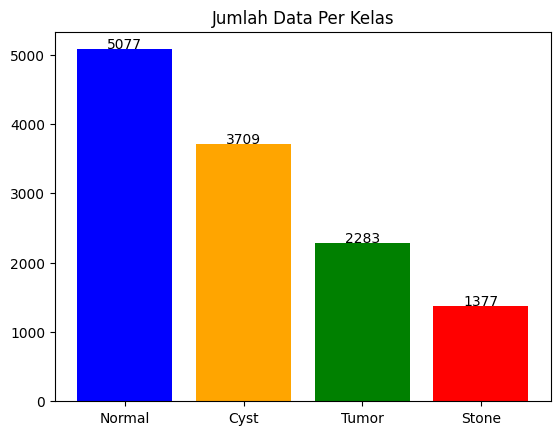

In [4]:
# Data Folders
data_folders = {
  "Normal": num_normal,
  "Cyst": num_cyst,
  "Tumor": num_tumor,
  "Stone": num_stone,
}

# Hitung jumlah file sekaligus ambil nama kategorinya
labels = list(data_folders.keys())
counts = list(data_folders.values()) # Corrected: Directly use the stored counts

# Tampilkan Grafik
plt.bar(labels, counts, color=['blue', 'orange', 'green', 'red'])
plt.title("Jumlah Data Per Kelas")

# Tambahkan angka di atas setiap batang agar jelas
for i, v in enumerate(counts):
  plt.text(i, v+10, str(v), ha='center')

plt.show()

"Karena datasets asli tidak seimbang, maka akan dilakukan pengambilan subset sebesar 1.000 citra per kelas (total 4.000 data) dilakukan untuk menerapkan strategi Undersampling. Hal ini bertujuan untuk menyeimbangkan distribusi data (Balanced Dataset) guna menghindari bias prediksi pada kelas mayoritas, serta mengoptimalkan efisiensi waktu komputasi tanpa mengurangi kemampuan model dalam mengekstraksi fitur-fitur penting."

In [5]:
# Buat folder baru untuk menyimpan subset dataset
subset_dir = os.path.join("/content/", "Dataset_Subset_1000") # Change dataset_path to a writable location
os.makedirs(subset_dir, exist_ok=True)

# Dictionary dari path sumber
categories = {
  "Normal": normal_cases_path,
  "Cyst": cyst_cases_path,
  "Tumor": tumor_cases_path,
  "Stone": stone_cases_path
}

# Proses menyalin 1000 file pertama
for label, source_path in categories.items():
  # Buat sub-folder untuk setiap class di dalam folder subset
  target_path = os.path.join(subset_dir, label)
  os.makedirs(target_path, exist_ok=True)

  # Ambil 1000 file pertama (diurutkan)
  files_to_copy = sorted(os.listdir(source_path))[:1000]

  # Copy file dari sumber ke target
  for file_name in files_to_copy:
    src_file = os.path.join(source_path, file_name)
    dst_file = os.path.join(target_path, file_name)
    shutil.copy(src_file, dst_file)

  print(f"Berhasil menyalin {len(files_to_copy)} file untuk class {label}")

print("\nDataset subset berhasil dibuat di:", subset_dir)

Berhasil menyalin 1000 file untuk class Normal
Berhasil menyalin 1000 file untuk class Cyst
Berhasil menyalin 1000 file untuk class Tumor
Berhasil menyalin 1000 file untuk class Stone

Dataset subset berhasil dibuat di: /content/Dataset_Subset_1000


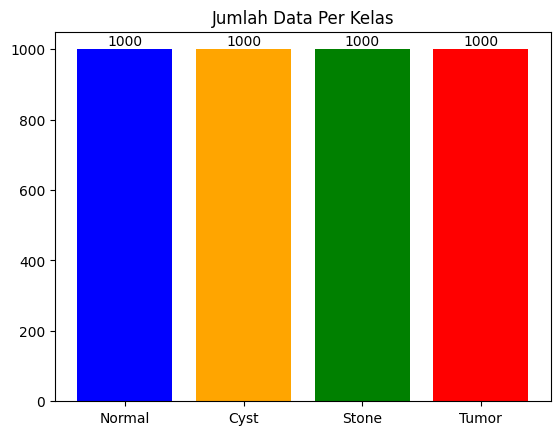

In [6]:
# Gabungkan label dan path dalam satu Dictionary
data_folders = {
  "Normal": "/content/Dataset_Subset_1000/Cyst",
  "Cyst": "/content/Dataset_Subset_1000/Normal",
  "Stone": "/content/Dataset_Subset_1000/Stone",
  "Tumor": "/content/Dataset_Subset_1000/Tumor"
}

# Hitung jumlah file sekaligus ambil nama kategorinya
labels = list(data_folders.keys())
counts = [len(os.listdir(p)) for p in data_folders.values()]

# Tampilkan Grafik
plt.bar(labels, counts, color=['blue', 'orange', 'green', 'red'])
plt.title("Jumlah Data Per Kelas")

# Tambahkan angka di atas setiap batang agar jelas
for i, v in enumerate(counts):
  plt.text(i, v+10, str(v), ha='center')

plt.show()

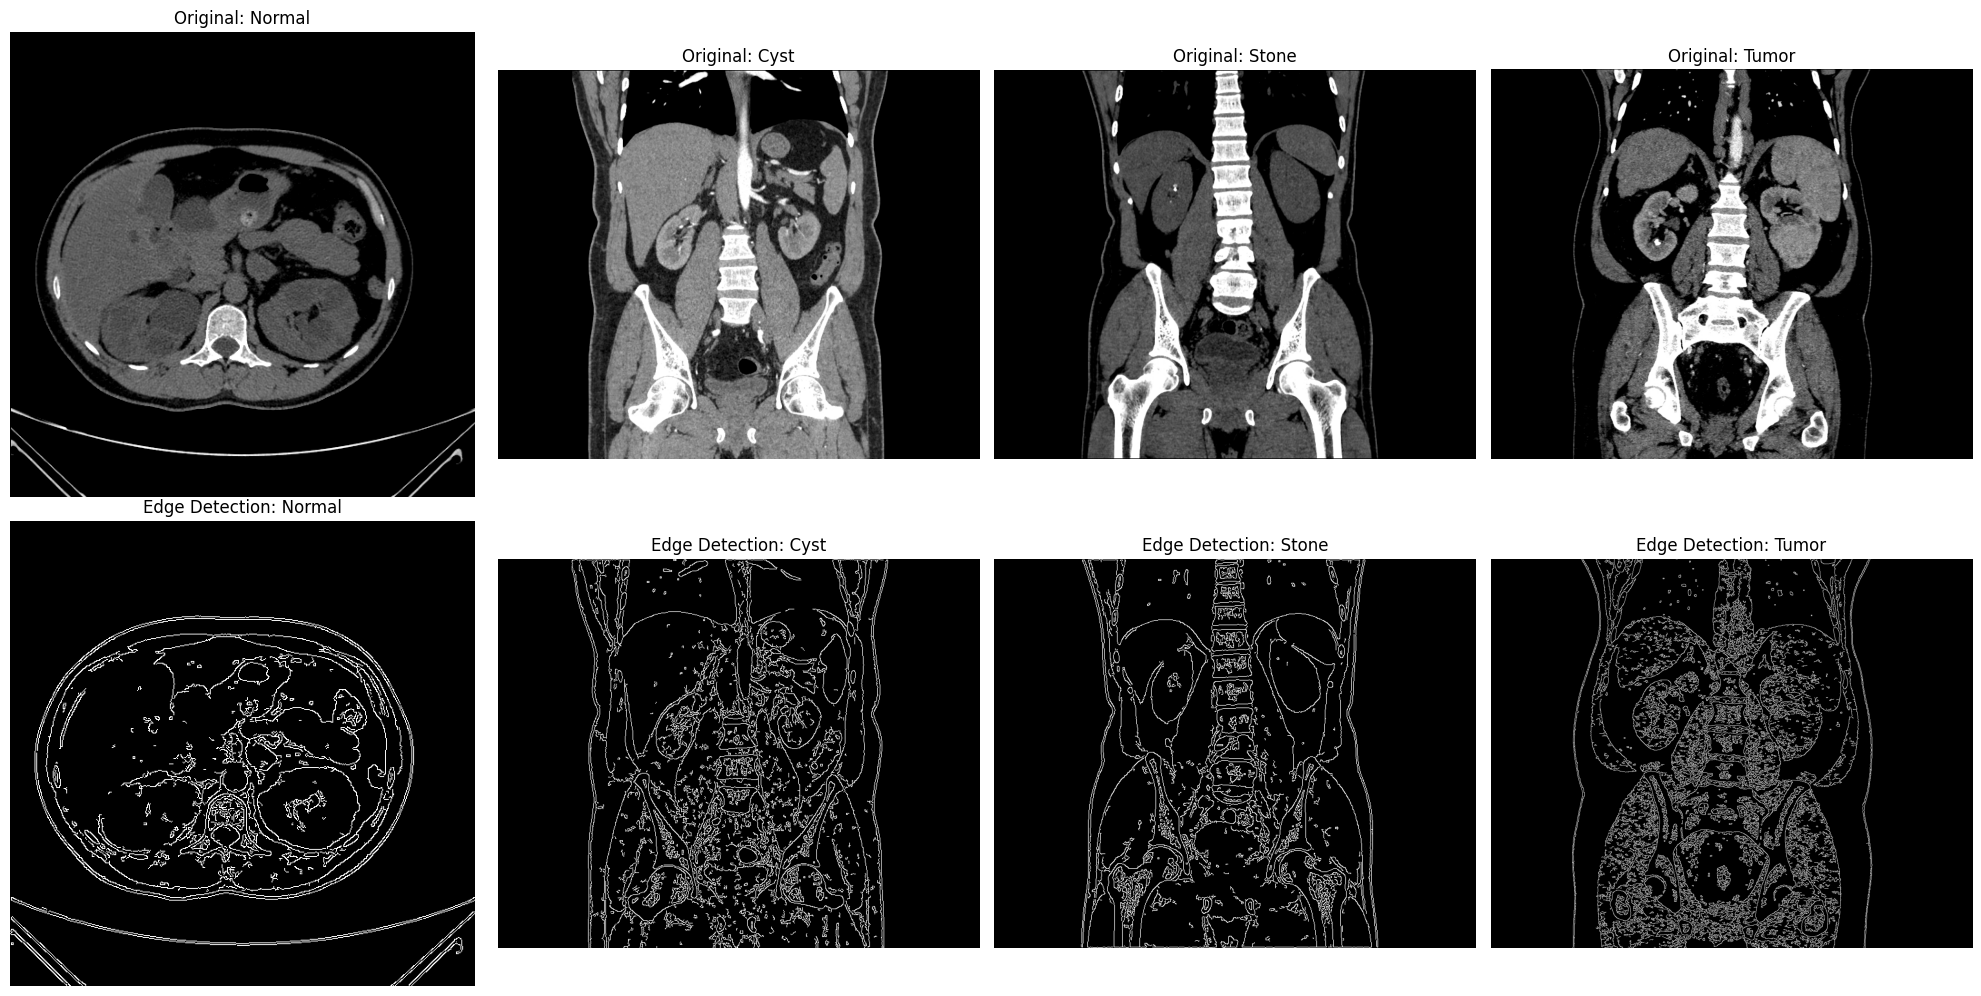

In [7]:
# Visualisasi Segmentasi Tepi (Edge Detection) yang pasti keluar gambarnya
plt.figure(figsize=(20, 10))

for i, (class_name, folder_path) in enumerate(data_folders.items()):
  # Ambil file pertama
  file_names = os.listdir(folder_path)
  if not file_names: continue

  img_path = os.path.join(folder_path, file_names[0])
  img = cv2.imread(img_path)
  img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

  # --- Teknik Segmentasi Medis: Canny Edge Detection ---
  # Ini akan mendeteksi garis tepi Tumor, Stone, atau Cyst
  edges = cv2.Canny(img_gray, 100, 200)

  # Tampilkan Gambar Asli
  plt.subplot(2, 4, i + 1)
  plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
  plt.title(f"Original: {class_name}")
  plt.axis('off')

  # Tampilkan Hasil Segmentasi Tepi
  plt.subplot(2, 4, i + 5)
  plt.imshow(edges, cmap='gray')
  plt.title(f"Edge Detection: {class_name}")
  plt.axis('off')

plt.tight_layout()
plt.show()

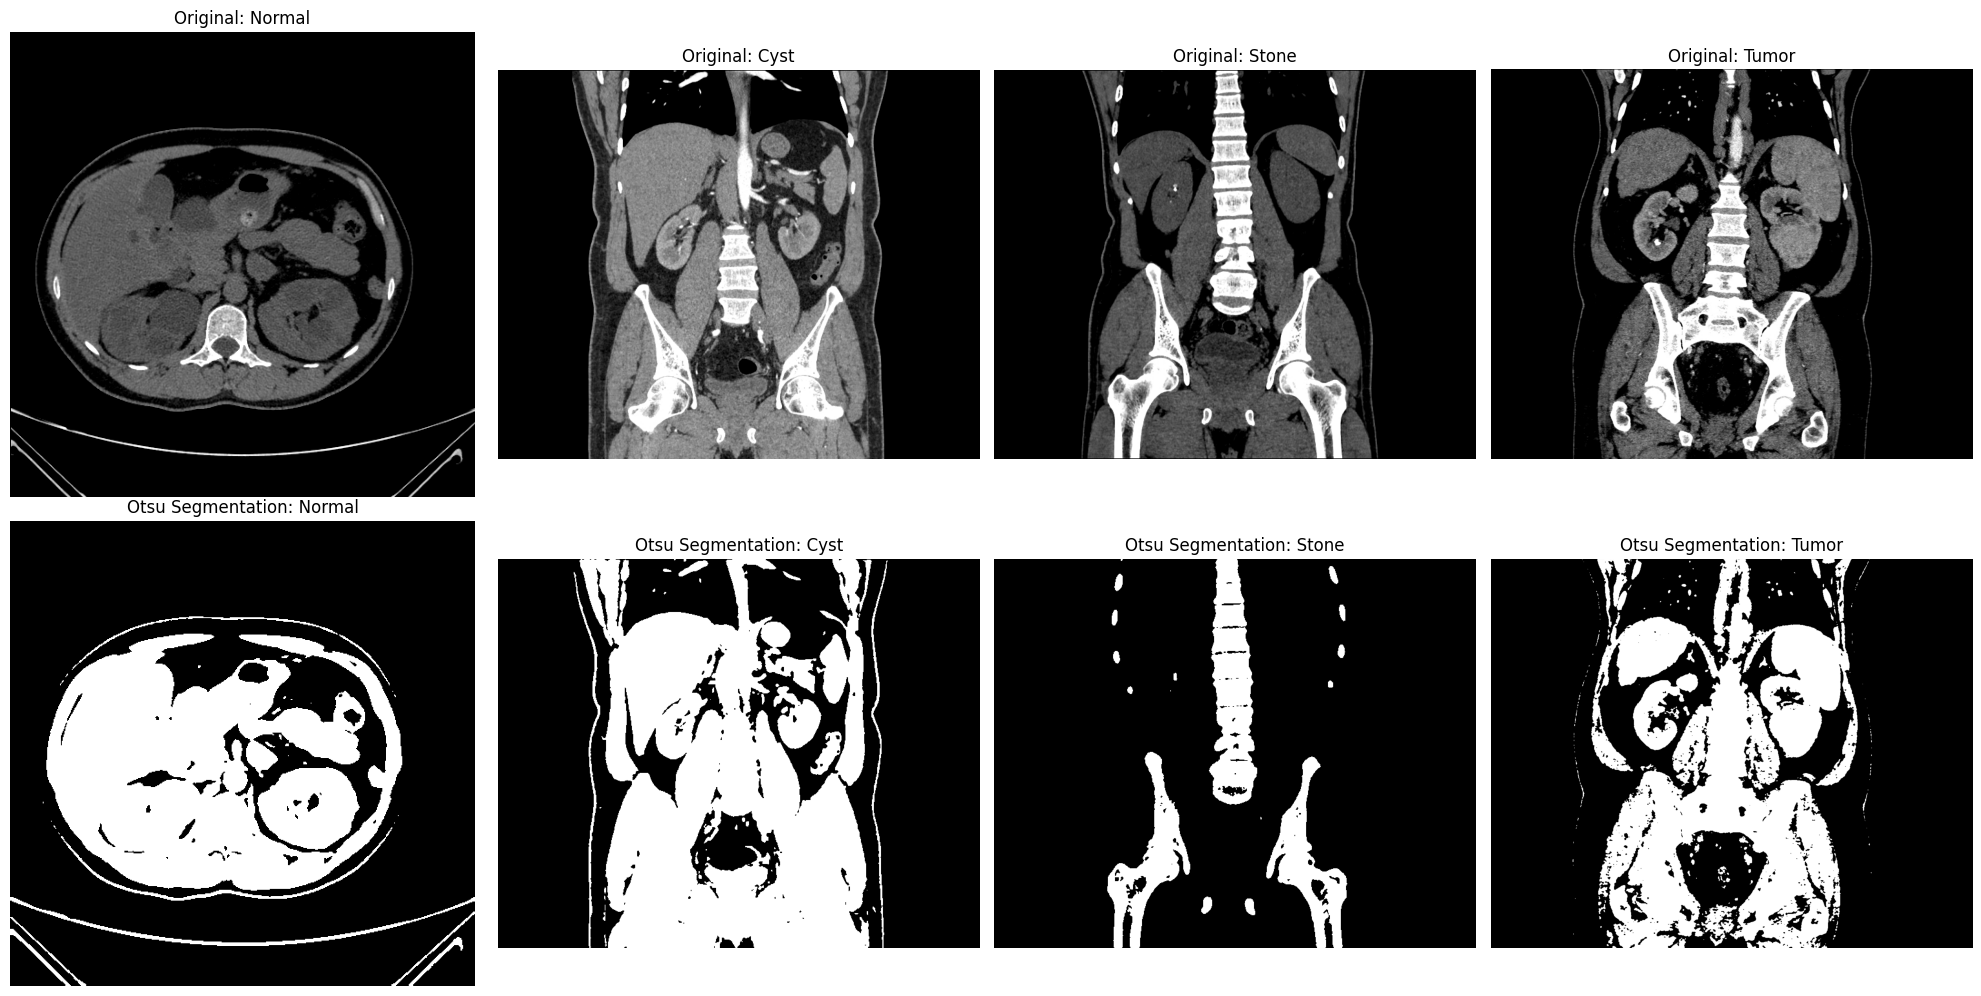

In [8]:
# Visualisasi Otsu Segmentation (Segmented Mask)
plt.figure(figsize=(20, 10))

for i, (class_name, folder_path) in enumerate(data_folders.items()):
  # Ambil file pertama dari folder masing-masing kelas
  file_names = os.listdir(folder_path)
  if not file_names: continue

  img_path = os.path.join(folder_path, file_names[0])
  img = cv2.imread(img_path)
  img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

  # --- Teknik Segmentasi Medis: Otsu Thresholding ---
  # 1. Gunakan Gaussian Blur untuk mengurangi (bintik-bintik halus)
  blur = cv2.GaussianBlur(img_gray, (5, 5), 0)

  # 2. Otsu secara otomatis mencari nilai ambang batas (threshold) optimal.
  ret, thresh = cv2.threshold(blur, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

  # Tampilkan Gambar Asli
  plt.subplot(2, 4, i + 1)
  plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
  plt.title(f"Original: {class_name}")
  plt.axis('off')

  # Tampilkan Hasil Otsu Segmentation
  plt.subplot(2, 4, i + 5)
  plt.imshow(thresh, cmap='gray')
  plt.title(f"Otsu Segmentation: {class_name}")
  plt.axis('off')

plt.tight_layout()
plt.show()

Untuk dataset CT-Kidney yang berisi citra CT-scan ginjal (Normal, Cyst, Tumor, Stone), teknik segmentasi citra bertujuan untuk memisahkan area ginjal dari latar belakang atau mengisolasi lesi (batu, kista, atau tumor) dari jaringan sehat.

In [9]:
def combined_segmentation_preprocess(img):
  # 1. Pastikan citra dalam format uint8 (0-255) agar OpenCV berfungsi
  img_uint8 = img.astype(np.uint8)

  # 2. Preprocessing dasar: Grayscale dan Blur
  gray = cv2.cvtColor(img_uint8, cv2.COLOR_BGR2GRAY)
  blur = cv2.GaussianBlur(gray, (5, 5), 0)

  # 3. Teknik 1: Otsu Thresholding (Mendapatkan "Isi" objek)
  _, otsu_mask = cv2.threshold(blur, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

  # 4. Teknik 2: Canny Edeg Detection (Mendapatkan "Garis Tepi")
  edges = cv2.Canny(blur, 100, 200)

  # 5. Gabungkan Keduanya dengan Bitwise OR
  hybrid_mask = cv2.bitwise_or(otsu_mask, edges)

  # 6. Konversi kembali ke 3-channel (RGB)
  hybrid_rgb = cv2.cvtColor(hybrid_mask, cv2.COLOR_GRAY2RGB)

  # 7. Final Step: Masukkan ke Preprocess Input bawaan EfficientNet
  final_img = tf.keras.applications.efficientnet.preprocess_input(hybrid_rgb)

  return final_img

Found 2800 images belonging to 4 classes.
Found 1200 images belonging to 4 classes.
Batch Size:  32


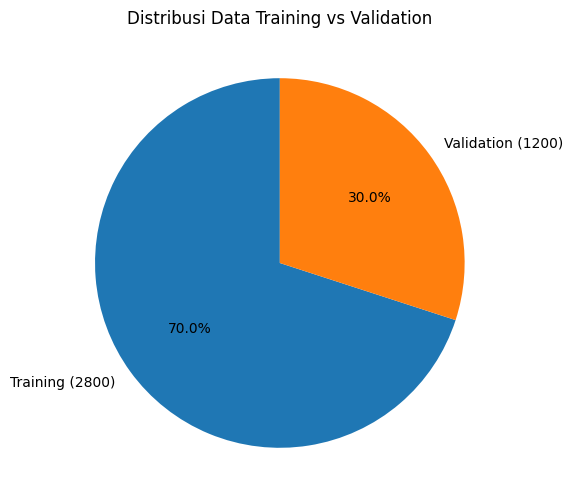

In [10]:
# Mengubah semua gambar dengan ukuran 224x224 piksel
IMG_HEIGHT = 224
IMG_WIDTH = 224
# Model belajar dari 32 gambar per satu langkah pelatihan
BATCH_SIZE = 32 # Hyperparameter (BATCH_SIZE = 32, 64, 128)

# Membuat data "tiruan" yang bervariasi dari data asli
train_datagen = ImageDataGenerator(
  # Mengubah nilai setiap piksel (0-255) menjadi rentang 0 hingga 1# Mengubah nilai setiap piksel (0-255) menjadi rentang 0 hingga 1
  preprocessing_function=combined_segmentation_preprocess,
  # Memutar dan menggeser gambar secara horizontal/vertikal.
  rotation_range=40,
  width_shift_range=0.2,
  height_shift_range=0.2,
  # Memberikan efek miring (distorsi) dan memperbesar/memperkecil gambar secara acak
  shear_range=0.2,
  zoom_range=0.2,
  # Membalik gambar secara horizontal (seperti cermin)
  horizontal_flip=True,
  # Mengubah tingkat kecerahan gambar (dari redup hingga terang)
  brightness_range=[0.5, 1.5],
  # Jika saat diputar ada bagian kosong di pojok gambar.
  fill_mode='nearest',
  # 20% for validation
  validation_split=0.3
)

# Data validasi tidak diberikan augmentasi (seperti rotasi atau flip)
validation_datagen = ImageDataGenerator(
  # Data validasi hanya di rescale saja
  # rescale=1./255,
  preprocessing_function=combined_segmentation_preprocess,
  validation_split=0.3
  # 30% data untuk validation
  # 70% data untuk training
)

# Bagian ini menghubungkan kode dengan folder di drive
train_generator = train_datagen.flow_from_directory(
  subset_dir, # Folder sumber diisi dengan 1000 gambar per kelas
  target_size=(IMG_HEIGHT, IMG_WIDTH),
  batch_size=BATCH_SIZE,
  class_mode='categorical', # Digunakan karena label memiliki 4 kelas
  subset='training',
  # Training: Mengambil 80% data untuk belajar
  # Validation: Mengambil 20% sisanya untuk ujian tengah semester model
  seed=42 # Memastikan pembagian data selalu sama setiap kali kode dijalankan
)

# Muat gambar dari parent_dir untuk validasi
validation_generator = validation_datagen.flow_from_directory(
  subset_dir,
  target_size=(IMG_HEIGHT, IMG_WIDTH),
  batch_size=BATCH_SIZE,
  class_mode='categorical',
  subset='validation',
  seed=42
)

# Ambil jumlah data dari generator
print("Batch Size: ", BATCH_SIZE)
counts = [train_generator.samples, validation_generator.samples]
labels = [f'Training ({counts[0]})', f'Validation ({counts[1]})']

# Plot diagram lingkaran (Pie Chart)
plt.figure(figsize=(6, 6))
plt.pie(counts, labels=labels, autopct='%1.1f%%', startangle=90)
plt.title("Distribusi Data Training vs Validation")
plt.show()

In [11]:
import pandas as pd
from sklearn.model_selection import train_test_split
import os

# Ambil semua path file dan label dari subset_dir (yang berisi 1000 per kelas)
filenames = []
labels = []

# Membaca folder kategori (Class)
for category in os.listdir(subset_dir):
    # Membuat alamat lengkap folder
    category_path = os.path.join(subset_dir, category)
    # Memastikan itu adalah folder
    if os.path.isdir(category_path):
        # Mendata setiap file gambar
        for file in os.listdir(category_path):
            filenames.append(os.path.join(category_path, file))
            labels.append(category)

# Membuat tabel (DataFrame)
df = pd.DataFrame({'filename': filenames, 'label': labels})

# Pembagian: 70% Train, 30% Sisanya (untuk Val + Test)
train_df, temp_df = train_test_split(df, test_size=0.3, stratify=df['label'], random_state=42)
# Pembagian Sisa (30%) menjadi dua: 15% Val dan 15% Test
val_df, test_df = train_test_split(temp_df, test_size=0.5, stratify=temp_df['label'], random_state=42)

print(f"Training Images: {len(train_df)} Images")
print(f"Validation Images: {len(val_df)} Images")
print(f"Testing Images: {len(test_df)} Images")

Training Images: 2800 Images
Validation Images: 600 Images
Testing Images: 600 Images


Found 2800 validated image filenames belonging to 4 classes.
Found 600 validated image filenames belonging to 4 classes.
Found 600 validated image filenames belonging to 4 classes.


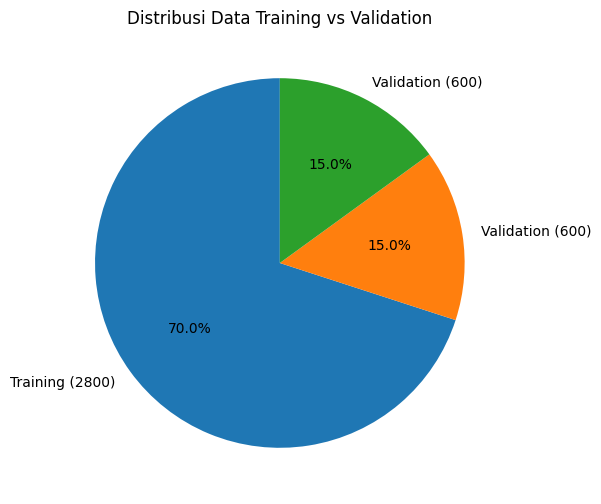

In [12]:
# Gunakan parameter augmentasi yang sudah kamu definisikan di train_datagen sebelumnya
# Gunakan rescale saja untuk val dan test

# 1. Train Generator (70%)
train_generator = train_datagen.flow_from_dataframe(
  train_df,
  x_col='filename',
  y_col='label',
  target_size=(IMG_WIDTH, IMG_HEIGHT),
  batch_size=BATCH_SIZE,
  class_mode='categorical',
  seed=42
)

# 2. Validation Generator (15%)
validation_generator = validation_datagen.flow_from_dataframe(
  val_df,
  x_col='filename',
  y_col='label',
  target_size=(IMG_WIDTH, IMG_HEIGHT),
  batch_size=BATCH_SIZE,
  class_mode='categorical',
  seed=42
)

# 3. Test Generator (15%) - Gunakan validation_datagen karena hanya butuh rescale
test_generator = validation_datagen.flow_from_dataframe(
  test_df,
  x_col='filename',
  y_col='label',
  target_size=(IMG_WIDTH, IMG_HEIGHT),
  batch_size=BATCH_SIZE,
  class_mode='categorical',
  shuffle=False, # Agar urutan hasil prediksi nanti mudah dicek
  seed=42
)

# 1. Ambil jumlah data dari generator
counts = [train_generator.samples, validation_generator.samples, test_generator.samples]
labels = [f'Training ({counts[0]})', f'Validation ({counts[1]})', f'Validation ({counts[2]})']

# 2. Plot diagram lingkaran (Pie Chart)
plt.figure(figsize=(6, 6))
plt.pie(counts, labels=labels, autopct='%1.1f%%', startangle=90)
plt.title("Distribusi Data Training vs Validation")
plt.show()

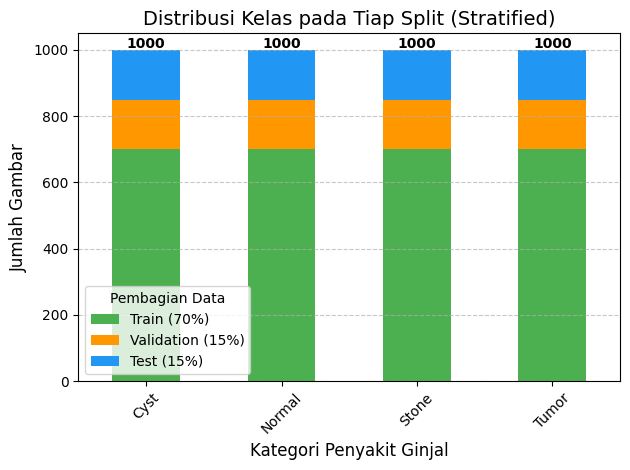

In [13]:
# Hitung jumlah data per kelas di masing-masing split
train_counts = train_df['label'].value_counts().sort_index()
val_counts = val_df['label'].value_counts().sort_index()
test_counts = test_df['label'].value_counts().sort_index()

# Siapkan Data untuk Plotting
categories = train_counts.index
df_plot = pd.DataFrame({ # Corrected 'Dataframe' to 'DataFrame'
  "Train (70%)": train_counts,
  "Validation (15%)": val_counts,
  "Test (15%)": test_counts
})

# Membuat Bar Chart
ax = df_plot.plot(kind='bar', stacked=True, color=['#4CAF50', '#FF9800', '#2196F3'])
plt.title("Distribusi Kelas pada Tiap Split (Stratified)", fontsize=14)
plt.xlabel("Kategori Penyakit Ginjal", fontsize=12)
plt.ylabel("Jumlah Gambar", fontsize=12)
plt.legend(title="Pembagian Data")
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Tambahkan label angka di atas setiap bar
for i, total in enumerate(df_plot.sum(axis=1)):
  ax.text(i, total + 5, int(total), ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

Kode ini mendefinisikan arsitektur jaringan saraf tiruan (Neural Network) menggunakan metode Transfer Learning. Model dibangun diatas fondasi yang sudah kuat (base_model) dan menambahkan "kepala" (top layers) baru untuk mengklasifikasi 4 jenis kondisi ginjal.

In [14]:
# 1. Definisikan Fungsi Pembuat Model
def build_efficientnet_model():
  # Memuat Base Model (EfficientNetB0)
  base_model = EfficientNetB0(
    # Mengganti dengan lapisan baru yang khusus menebak 4 kondisi ginjal.
    include_top = False,
    # Menggunakan bobot (kecerdasan) yang sudah dipelajari dari (1,2 juta gambar)
    weights = 'imagenet',
    input_tensor = None,
    # Menentukan ukuran gambar masuk (224x224 piksel dengan 3 saluran warna (RGB).
    input_shape = (IMG_HEIGHT, IMG_WIDTH, 3),
    pooling = None,
    classifier_activation = "softmax",
    name = "efficientnetb0"
  )

  # Mengunci pengetahuan asli base_model agar tidak rusak saat melatih lapisan baru.
  base_model.trainable = False

  # Menyusun Arsitektur Sequential
  model = models.Sequential([
    # Model ini sudah dilatih menggunakan jutaan gambar umum (ImageNet)
    base_model,
    # Mengurangi dimensi data secara drastis untuk mencegah overfitting
    layers.GlobalAveragePooling2D(),
    # Mempelajari hubungan logika antara tekstur gambar dengan jenis penyakit
    layers.Dense(256, activation='relu'),
    # Lapisan ini menstabilkan hasil perhitungan dari lapisan sebelumnya
    layers.BatchNormalization(),
    # Teknik pengamanan yang secara acak "mematikan" 30% saraf (neuron)
    layers.Dropout(0.3),
    # Lapisan terakhir yang menentukan hasil akhir diagnosa.
    layers.Dense(4, activation='softmax') # 4 Kelas: Normal, Cyst, Tumor, Stone
  ])

  auc_metric = tf.keras.metrics.AUC(multi_label=True, name='auc')

  # Kompilasi Model
  model.compile(
    # Ini adalah algoritma optimasi yang bertugas memperbarui bobot (parameter)
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.0001), # Hyperparameter
    loss='categorical_crossentropy',
    metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
  )
  return model

# 2. Panggil Fungsi untuk Membuat Model
efficientNet_model = build_efficientnet_model()

# 3. Tampilkan Ringkasan Arsitektur (Model Summary)
# Ini akan menampilkan jumlah parameter dan urutan layer secara detail
efficientNet_model.summary()

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │         1,028 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,379,559 (16.71 MB)

 Trainable params: 329,476 (1.26 MB)

 Non-trainable params: 4,050,083 (15.45 MB)

In [15]:
# 4. Mulai Proses Pelatihan
history = efficientNet_model.fit(
  train_generator,
  epochs=30, # Hyperparameter
  validation_data=validation_generator,
  verbose=1
)

Epoch 1/30
88/88 ━━━━━━━━━━━━━━━━━━━━ 330s 4s/step - accuracy: 0.3824 - loss: 1.6895 - val_accuracy: 0.5750 - val_loss: 1.0980
Epoch 2/30
88/88 ━━━━━━━━━━━━━━━━━━━━ 324s 4s/step - accuracy: 0.5968 - loss: 1.0790 - val_accuracy: 0.7133 - val_loss: 0.8344
Epoch 3/30
88/88 ━━━━━━━━━━━━━━━━━━━━ 345s 4s/step - accuracy: 0.6523 - loss: 0.8751 - val_accuracy: 0.7367 - val_loss: 0.6910
Epoch 4/30
88/88 ━━━━━━━━━━━━━━━━━━━━ 319s 4s/step - accuracy: 0.6688 - loss: 0.8538 - val_accuracy: 0.8233 - val_loss: 0.5385
Epoch 5/30
88/88 ━━━━━━━━━━━━━━━━━━━━ 343s 4s/step - accuracy: 0.7251 - loss: 0.7288 - val_accuracy: 0.8017 - val_loss: 0.5011
Epoch 6/30
88/88 ━━━━━━━━━━━━━━━━━━━━ 356s 4s/step - accuracy: 0.7279 - loss: 0.7011 - val_accuracy: 0.7900 - val_loss: 0.5010
Epoch 7/30
88/88 ━━━━━━━━━━━━━━━━━━━━ 312s 4s/step - accuracy: 0.7716 - loss: 0.5998 - val_accuracy: 0.8250 - val_loss: 0.4453
Epoch 8/30
88/88 ━━━━━━━━━━━━━━━━━━━━ 320s 4s/step - accuracy: 0.7478 - loss: 0.6346 - val_accuracy: 0.8400 - v

"\nplt.subplot(1, 3, 3)\nplt.plot(history.history['auc'], label='Train AUC')\nplt.plot(history.history['val_auc'], label='Val AUC')\nplt.title('AUC Score vs Epochs')\nplt.legend()\n\nplt.tight_layout()\nplt.show()\n"

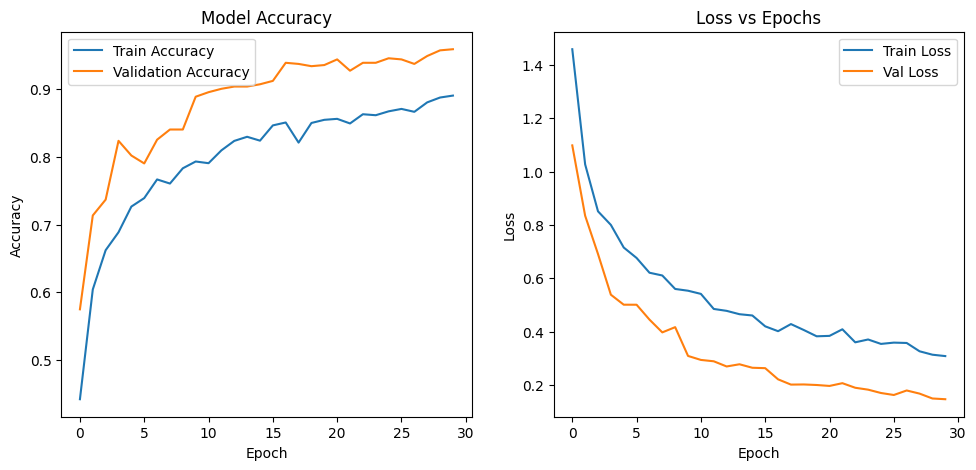

In [25]:
# Membuat visualisasi untuk Accuracy, Loss, dan AUC
plt.figure(figsize=(18, 5))

# Plot Accuracy
plt.subplot(1, 3, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Plot Loss
plt.subplot(1, 3, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Loss vs Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

# Plot AUC
'''
plt.subplot(1, 3, 3)
plt.plot(history.history['auc'], label='Train AUC')
plt.plot(history.history['val_auc'], label='Val AUC')
plt.title('AUC Score vs Epochs')
plt.legend()

plt.tight_layout()
plt.show()
'''

In [28]:
# Reset generator ke awal sebelum prediksi
test_generator.reset()

start_time = time.time()
Y_pred = efficientNet_model.predict(test_generator)
end_time = time.time()

inference_time = end_time - start_time
y_pred = np.argmax(Y_pred, axis=1)
y_true = test_generator.classes # Mengambil label asli sesuai urutan folder

# Hitung Akurasi
test_accuracy = accuracy_score(y_true, y_pred)

# Hitung waktu prediksi per gambar
inference_time_per_image = inference_time / test_generator.samples

print(f"--- Hasil Evaluasi Data Test ---")
print(f"Akurasi Testing : {test_accuracy:.4f}")
print(f"Total Waktu Prediksi : {inference_time:.2f} detik")
print(f"Waktu Prediksi per Gambar : {inference_time_per_image:.4f} detik")


19/19 ━━━━━━━━━━━━━━━━━━━━ 49s 3s/step
--- Hasil Evaluasi Data Test ---
Akurasi Testing : 0.9400
Total Waktu Prediksi : 50.00 detik
Waktu Prediksi per Gambar : 0.0833 detik


In [29]:
from sklearn.metrics import classification_report

# 2. Menampilkan Classification Report
# Ini akan menunjukkan Precision, Recall, dan F1-Score untuk setiap jenis penyakit ginjal
print("\n--- Classification Report ---")
class_labels = list(train_generator.class_indices.keys())
# Menambahkan parameter digits=3 untuk menampilkan 3 angka di belakang koma
cls_report = classification_report(y_true, y_pred, target_names=class_labels, digits=3)
print(cls_report)


--- Classification Report ---
              precision    recall  f1-score   support

        Cyst      0.978     0.893     0.934       150
      Normal      0.948     0.973     0.961       150
       Stone      0.868     0.967     0.915       150
       Tumor      0.979     0.927     0.952       150

    accuracy                          0.940       600
   macro avg      0.943     0.940     0.940       600
weighted avg      0.943     0.940     0.940       600




--- Confusion Matrix ---


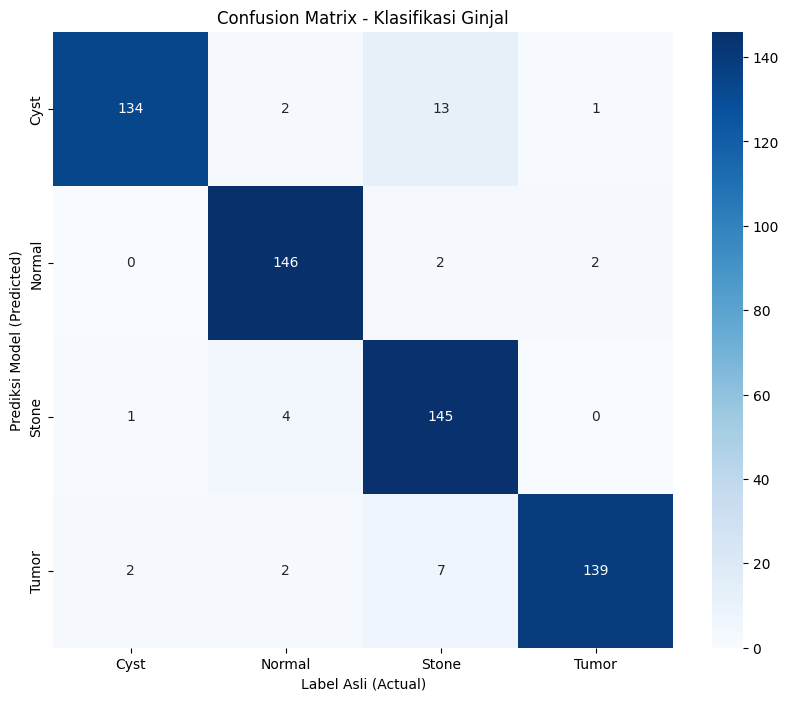

In [30]:
# 3. Membuat Confusion Matrix (Visual)
print("\n--- Confusion Matrix ---")
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_labels, yticklabels=class_labels)
plt.title('Confusion Matrix - Klasifikasi Ginjal')
plt.xlabel('Label Asli (Actual)')
plt.ylabel('Prediksi Model (Predicted)')
plt.show()

Saving Stone- (1020).jpg to Stone- (1020).jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 122ms/step


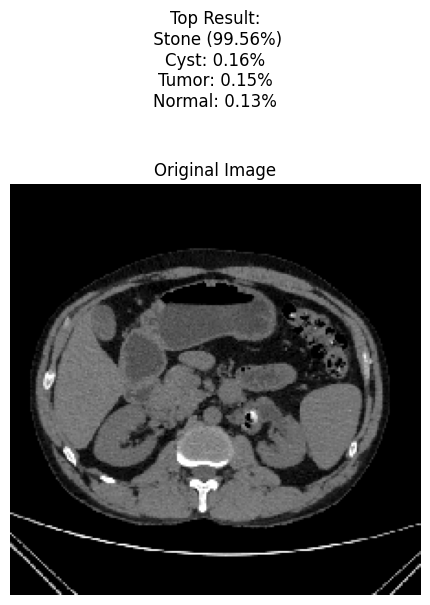

In [32]:
from google.colab import files
from tensorflow.keras.preprocessing import image
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
import cv2

def predict_with_upload(model, class_indices):
  # 1. Trigger fitur upload file
  uploaded = files.upload()

  for file_name in uploaded.keys():
    # 2. Load gambar asli untuk tampilan visual
    img = image.load_img(file_name, target_size=(IMG_HEIGHT, IMG_WIDTH))
    img_array = image.img_to_array(img)

    # 3. PROSES SEGMENTASI (Wajib sama dengan saat training)
    img_segmented = combined_segmentation_preprocess(img_array)

    # Tambahkan dimensi batch (1, 224, 224, 3)
    img_ready = np.expand_dims(img_segmented, axis=0)

    # 4. Prediksi
    predictions = model.predict(img_ready)[0]
    class_names = list(class_indices.keys())

    # 5. Mengolah Hasil
    results = []
    for i in range(len(class_names)):
        results.append((class_names[i], predictions[i] * 100))

    # Sort dari persentase tertinggi
    results.sort(key=lambda x: x[1], reverse=True)

    # 6. Visualisasi (Hanya Original Image)
    plt.figure(figsize=(6, 6))

    plt.imshow(img)
    plt.title("Original Image")
    plt.axis('off')

    # Tampilkan Teks Prediksi
    display_text = f"Top Result:\n {results[0][0]} ({results[0][1]:.2f}%)\n"
    for name, prob in results[1:]:
      display_text += f"{name}: {prob:.2f}%\n"

    plt.suptitle(display_text, fontsize=12, y=1)
    plt.tight_layout()
    plt.show()

# Cara Menjalankan:
predict_with_upload(efficientNet_model, train_generator.class_indices)
